In [19]:
# Data Pre-processing Example

import pandas as pd
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

# Load dataset
iris = load_iris()
X = iris.data
y = iris.target

df = pd.DataFrame(X, columns=iris.feature_names)

print("Original Data")
print(df.head())

# Standardization
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Train Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.3, random_state=42
)

print("Training Data Shape:", X_train.shape)
print("Testing Data Shape:", X_test.shape)

Original Data
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)
0                5.1               3.5                1.4               0.2
1                4.9               3.0                1.4               0.2
2                4.7               3.2                1.3               0.2
3                4.6               3.1                1.5               0.2
4                5.0               3.6                1.4               0.2
Training Data Shape: (105, 4)
Testing Data Shape: (45, 4)


In [20]:
# Model Selection using Cross Validation

from sklearn.model_selection import cross_val_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.datasets import load_iris

iris = load_iris()
X = iris.data
y = iris.target

model = DecisionTreeClassifier()

scores = cross_val_score(model, X, y, cv=5)

print("Cross Validation Scores:", scores)
print("Average Accuracy:", scores.mean())

Cross Validation Scores: [0.96666667 0.96666667 0.9        0.96666667 1.        ]
Average Accuracy: 0.9600000000000002


In [21]:
# XGBoost Classification

from xgboost import XGBClassifier
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

iris = load_iris()
X = iris.data
y = iris.target

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

model = XGBClassifier()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("XGBoost Accuracy:", accuracy_score(y_test, y_pred))

XGBoost Accuracy: 1.0


In [22]:
# Filter Feature Selection using Chi-Square

from sklearn.datasets import load_iris
from sklearn.feature_selection import SelectKBest, chi2
import pandas as pd

iris = load_iris()
X = iris.data
y = iris.target

df = pd.DataFrame(X, columns=iris.feature_names)

selector = SelectKBest(score_func=chi2, k=2)
X_new = selector.fit_transform(X, y)

selected_features = df.columns[selector.get_support()]

print("Selected Features:")
print(selected_features)

Selected Features:
Index(['petal length (cm)', 'petal width (cm)'], dtype='object')


In [23]:
# Wrapper Feature Selection using Recursive Feature Elimination

from sklearn.datasets import load_iris
from sklearn.feature_selection import RFE
from sklearn.tree import DecisionTreeClassifier

iris = load_iris()
X = iris.data
y = iris.target

model = DecisionTreeClassifier()

rfe = RFE(model, n_features_to_select=2)
X_rfe = rfe.fit_transform(X, y)

print("Selected Feature Indices:")
print(rfe.get_support(indices=True))

Selected Feature Indices:
[2 3]


In [24]:
# Self Organizing Map Example
from minisom import MiniSom
from sklearn.datasets import load_iris
from sklearn.preprocessing import MinMaxScaler

iris = load_iris()
X = iris.data

scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

som = MiniSom(x=7, y=7, input_len=4, sigma=1.0, learning_rate=0.5)

som.random_weights_init(X_scaled)
som.train_random(X_scaled, 100)

print("SOM training completed")

SOM training completed


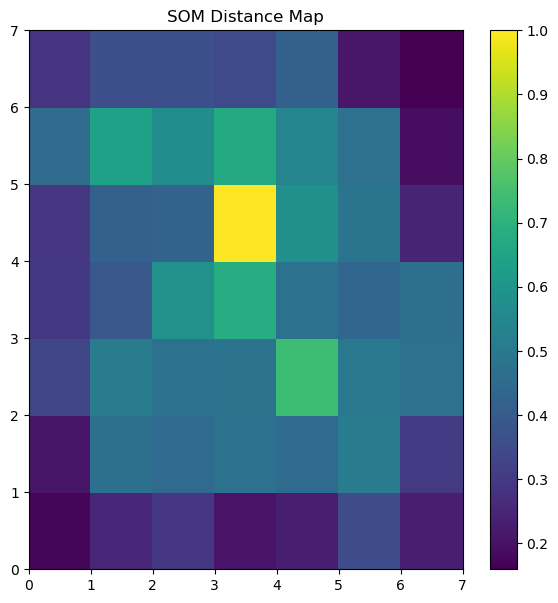

In [25]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7,7))
plt.pcolor(som.distance_map())
plt.colorbar()
plt.title("SOM Distance Map")
plt.show()